# XGBoost Baseline - Playground Series S6E5

**Target:** `PitNextLap` (이진, 양성 19.9%)
**Metric:** ROC AUC
**Strategy:** 5-Fold StratifiedKFold, LabelEncoder for cats, no sample weighting (AUC robust to imbalance)

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')
print(f'Train: {train.shape}, Test: {test.shape}')

Train: (439140, 16), Test: (188165, 15)


## 1. Preprocessing

- `Driver`/`Compound`/`Race`를 LabelEncoder. Driver는 train-only 86개가 있으므로 test에서 unseen 발생 시 -1로 매핑하여 안전 처리.
- 드롭: `id`, target.

In [2]:
TARGET = 'PitNextLap'
CAT_COLS = ['Driver', 'Compound', 'Race']

y = train[TARGET].astype(int).values

label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    seen = set(le.classes_)
    test[col] = test[col].astype(str).map(lambda v: le.transform([v])[0] if v in seen else -1)
    label_encoders[col] = le

drop_cols = ['id', TARGET]
feature_cols = [c for c in train.columns if c not in drop_cols]
X      = train[feature_cols]
X_test = test[feature_cols]

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'X: {X.shape}, X_test: {X_test.shape}')
print(f'Target distribution: {np.bincount(y)} (pos rate = {y.mean():.4f})')

Features (14): ['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
X: (439140, 14), X_test: (188165, 14)
Target distribution: [351759  87381] (pos rate = 0.1990)


## 2. Training (5-Fold StratifiedKFold)

In [3]:
N_FOLDS = 5
SEED = 42

xgb_params = dict(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof  = np.zeros(len(X))
test_pred = np.zeros(len(X_test))
fold_scores = []
last_model = None

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = XGBClassifier(**xgb_params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=200)

    oof[va_idx] = model.predict_proba(X_va)[:, 1]
    test_pred += model.predict_proba(X_test)[:, 1] / N_FOLDS

    sc = roc_auc_score(y_va, oof[va_idx])
    fold_scores.append(sc)
    print(f'Fold {fold}: AUC = {sc:.5f}')
    last_model = model

print('=' * 50)
print(f'Overall OOF AUC : {roc_auc_score(y, oof):.5f}')
print(f'Mean Fold AUC   : {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})')

[0]	validation_0-auc:0.91971
[200]	validation_0-auc:0.94734
[400]	validation_0-auc:0.94938
[600]	validation_0-auc:0.95006
[800]	validation_0-auc:0.95028
[999]	validation_0-auc:0.95031
Fold 0: AUC = 0.95031
[0]	validation_0-auc:0.91947
[200]	validation_0-auc:0.94581
[400]	validation_0-auc:0.94772
[600]	validation_0-auc:0.94817
[800]	validation_0-auc:0.94826
[999]	validation_0-auc:0.94819
Fold 1: AUC = 0.94819
[0]	validation_0-auc:0.92023
[200]	validation_0-auc:0.94658
[400]	validation_0-auc:0.94849
[600]	validation_0-auc:0.94900
[800]	validation_0-auc:0.94906
[999]	validation_0-auc:0.94905
Fold 2: AUC = 0.94905
[0]	validation_0-auc:0.91884
[200]	validation_0-auc:0.94564
[400]	validation_0-auc:0.94755
[600]	validation_0-auc:0.94821
[800]	validation_0-auc:0.94844
[999]	validation_0-auc:0.94840
Fold 3: AUC = 0.94840
[0]	validation_0-auc:0.92049
[200]	validation_0-auc:0.94662
[400]	validation_0-auc:0.94861
[600]	validation_0-auc:0.94923
[800]	validation_0-auc:0.94942
[999]	validation_0-auc:

## 3. Analysis

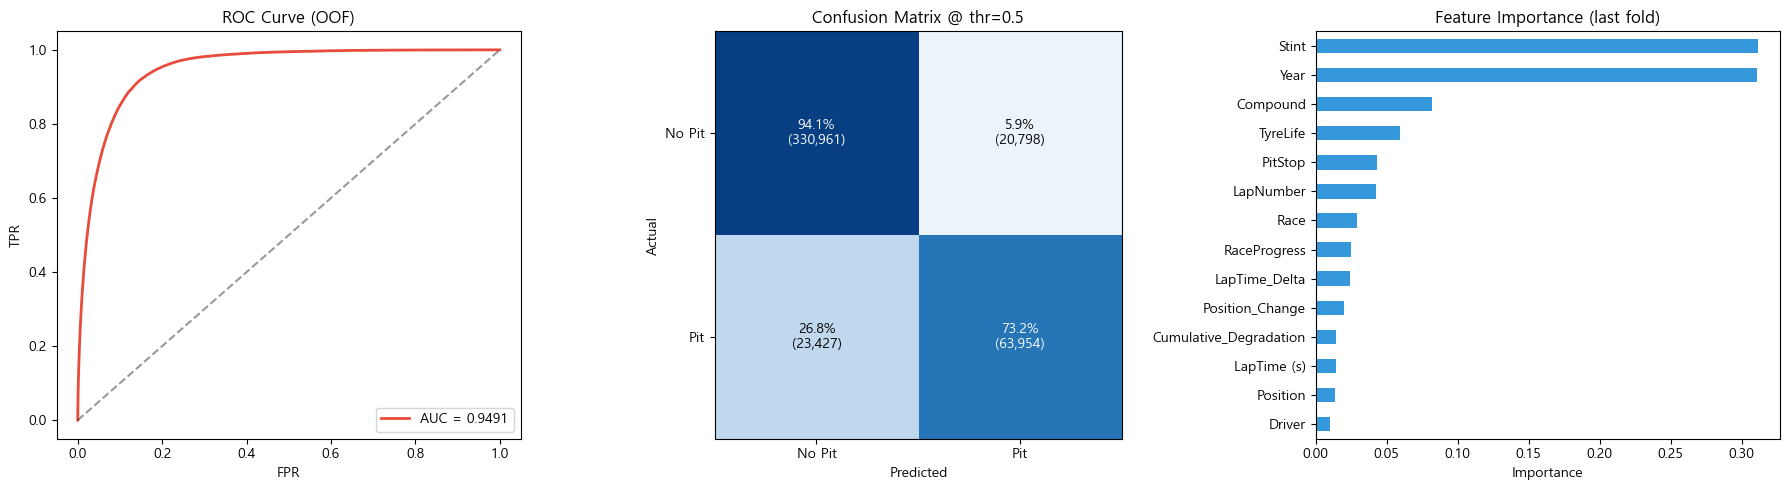

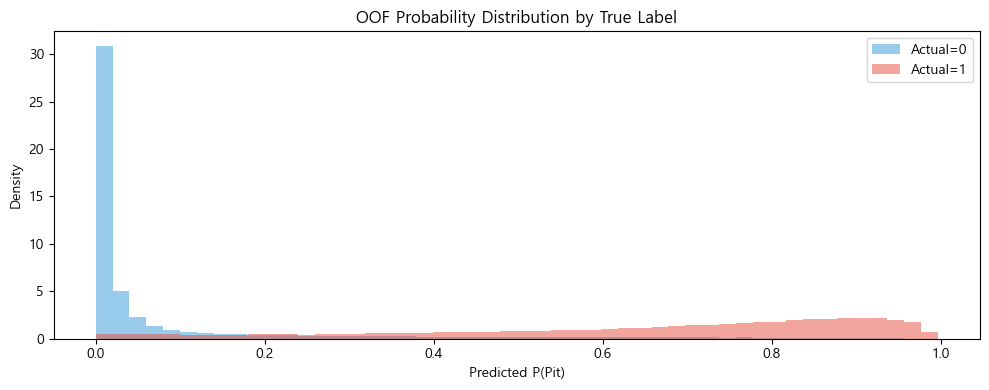

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import roc_curve, confusion_matrix

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
fpr, tpr, _ = roc_curve(y, oof)
auc_overall = roc_auc_score(y, oof)
axes[0].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'AUC = {auc_overall:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve (OOF)')
axes[0].legend()

# Confusion @ threshold 0.5
pred_lbl = (oof >= 0.5).astype(int)
cm = confusion_matrix(y, pred_lbl)
cm_pct = cm / cm.sum(axis=1, keepdims=True)
axes[1].imshow(cm_pct, cmap='Blues', vmin=0, vmax=1)
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['No Pit', 'Pit'])
axes[1].set_yticklabels(['No Pit', 'Pit'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix @ thr=0.5')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{cm_pct[i,j]:.1%}\n({cm[i,j]:,})',
                     ha='center', va='center', fontsize=10,
                     color='white' if cm_pct[i, j] > 0.5 else 'black')

# Feature importance (last fold)
imp = pd.Series(last_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
imp.plot(kind='barh', ax=axes[2], color='#3498db')
axes[2].set_title('Feature Importance (last fold)')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# OOF prob distribution
fig2, ax = plt.subplots(figsize=(10, 4))
for label, color in [(0, '#3498db'), (1, '#e74c3c')]:
    ax.hist(oof[y == label], bins=50, alpha=0.5, label=f'Actual={label}', color=color, density=True)
ax.set_xlabel('Predicted P(Pit)'); ax.set_ylabel('Density')
ax.set_title('OOF Probability Distribution by True Label')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Submission

In [5]:
submission = pd.DataFrame({
    'id': test['id'],
    'PitNextLap': test_pred,
})
print(f'Submission shape: {submission.shape}')
print(f'Pred prob — mean {submission["PitNextLap"].mean():.4f}, std {submission["PitNextLap"].std():.4f}')
print(f'min {submission["PitNextLap"].min():.4f}, max {submission["PitNextLap"].max():.4f}')

submission.to_csv('../submissions/submission_xgb_baseline.csv', index=False)
print('\nSaved to ../submissions/submission_xgb_baseline.csv')
submission.head()

Submission shape: (188165, 2)
Pred prob — mean 0.1973, std 0.2974
min 0.0000, max 0.9951

Saved to ../submissions/submission_xgb_baseline.csv


,id,PitNextLap
0,439140,0.005667
1,439141,0.005131
2,439142,0.002850
3,439143,0.169458
4,439144,0.901432
